# TorchRL

Let's start our first tutorial! Here we'll go over how to create *Environments* and how *agents* can take actions in these environments.

This notebook was modified from the official tutorials provided by torchRL: 

**Get started with Environments, TED and transforms**
Author: `Vincent Moens <https://github.com/vmoens>`
url: https://docs.pytorch.org/rl/stable/tutorials

# Install TorchRL

First let's install torchrl and tensordict.


In [ ]:
#!pip install tensordict
#!pip install torchrl

# Environments-agents

Let's start by creating an environment. Let's create the pendulum environment. You can see more about this environment (and others) here: https://gymnasium.farama.org/environments/classic_control/pendulum/

In [ ]:
from torchrl.envs import GymEnv

env = GymEnv("Pendulum-v1")


Environments in TorchRL have two crucial methods: 

1. *reset()*, which initiates an episode, and 
2. *step()*, which executes an action selected by the actor. 

In TorchRL, environment methods read and write TensorDict instances. Essentially, TensorDict is a generic key-based data carrier for tensors. The benefit of using TensorDict over plain tensors is that it enables us to handle simple and complex data structures interchangeably. As our function signatures are very generic, it eliminates the challenge of accommodating different data formats. In simpler terms, after this brief tutorial, you will be capable of operating on both simple and highly complex environments, as their user-facing API is identical and simple!

Let’s create an environment, reset it, and see what a tensordict instance looks like:

In [24]:
data_out = env.reset()
print(data_out)

TensorDict(
    fields={
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        observation: Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, is_shared=False),
        terminated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        truncated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)


The tensorDict above shows what keys it holds: 

* done: did the agent reach the end of an episode -- size [1], type [boolean]
* observation: what does the agent know (stimuli) -- size [3], type [float32] 
* terminated: did the agent-environment interaction end naturally (reached the end of a maze) -- size [1], type [boolean]
* truncated: did the agent-environment interaction end un-naturally (time ran out) -- size [1], type [boolean]

Each has a size and a data type.

Let's see what values are in the observation key.

In [25]:
data_out["observation"]

tensor([ 0.6011,  0.7992, -0.5180])

These are the observations of the agent (a little pendulum) and represent the x-y coordinates of the pendulum’s free end and its angular velocity.

Now let’s take a random action in the action space. For the pendulum environment we can take action by applying some amount of torque on the free end of the pendulum (min -2.0, max 2.0).

Let's apply a random action.

In [26]:
data_out_with_action = env.rand_action(data_out)
print(data_out_with_action)

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        observation: Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, is_shared=False),
        terminated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        truncated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)


This tensordict has the same structure as the one obtained from EnvBase() with an additional "action" entry. You can access the action easily, like you would do with a regular dictionary:

In [27]:
print(data_out_with_action["action"])

tensor([-0.7536])


That's the amount of torque you'd like to apply to the pendulum.

We now need to pass this action to the environment. We’ll be passing the entire tensordict to the step method, since there might be more than one tensor to be read in more advanced cases like Multi-Agent RL or stateless environments:

In [28]:
stepped_data = env.step(data_out_with_action)
print(stepped_data)

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, is_shared=False),
                reward: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([]),
            device=None,
            is_shared=False),
        observation: Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, is_shared=False),
        terminat

Again, this new tensordict is identical to the previous one except for the fact that it has a "next" entry (itself a tensordict!) containing the observation, reward and done state resulting from our action.

We call this format TED, for [TorchRL Episode Data format](https://docs.pytorch.org/rl/stable/reference/data_datasets.html#ted-format). It is the ubiquitous way of representing data in the library, both dynamically like here, or statically with offline datasets.

The last bit of information you need to run a rollout in the environment is how to bring that "next" entry at the root to perform the next step. TorchRL provides a dedicated step_mdp() function that does just that: it filters out the information you won’t need and delivers a data structure corresponding to your observation after a step in the Markov Decision Process, or MDP.

In [29]:
from torchrl.envs import step_mdp

data = step_mdp(stepped_data)
print(data)

TensorDict(
    fields={
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        observation: Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, is_shared=False),
        terminated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        truncated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)


### Environment rollouts

Writing down those three steps:

* computing an action, 
* making a step, 
* moving in the MDP

can be a bit tedious and repetitive. Fortunately, TorchRL provides a nice rollout() function that allows you to run them in a closed loop at will:

In [32]:
rollout_data = env.rollout(max_steps=10)
print(rollout_data)

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([10, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                reward: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([10]),
            device=None,
            is_shared=False),
        observation: Tensor(shape=torch.Size([10, 3]), device=cpu, dtype=torch.float32, 

This data looks pretty much like the stepped_data above with the exception of its batch-size, which now equates the number of steps we provided through the max_steps argument. The magic of tensordict doesn’t end there: if you’re interested in a single transition of this environment, you can index the tensordict like you would index a tensor:

In [33]:
transition = rollout_data[3]
print(transition)

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, is_shared=False),
                reward: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([]),
            device=None,
            is_shared=False),
        observation: Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, is_shared=False),
        terminat

TensorDict will automatically check if the index you provided is a key (in which case we index along the key-dimension) or a spatial index like here.

Executed as such (without a policy), the rollout method may seem rather useless: it just runs random actions. If a policy is available, it can be passed to the method and used to collect data.

Nevertheless, it can useful to run a naive, policyless rollout at first to check what is to be expected from an environment at a glance.

To appreciate the versatility of TorchRL’s API, consider the fact that the rollout method is universally applicable. It functions across all use cases, whether you’re working with a single environment like this one, multiple copies across various processes, a multi-agent environment, or even a stateless version of it!

**Things to try**

When creating the environment at the top of this notebook, try changing the environment to "CartPole-v1". Walk through the code and see how the tensodict has changed.

Here's a link to the cartpole environment: https://gymnasium.farama.org/environments/classic_control/cart_pole/

In [ ]:
### Transforming an environment

Most of the time, you’ll want to modify the output of the environment to better suit your requirements. For example, you might want to monitor the number of steps executed since the last reset, resize images, or stack consecutive observations together.

In this section, we’ll examine a simple transform, the StepCounter transform. The complete list of transforms can be found [here](https://docs.pytorch.org/rl/stable/reference/envs_transforms.html#transforms).

The transform is integrated with the environment through a TransformedEnv:

In [38]:
from torchrl.envs import StepCounter, TransformedEnv

transformed_env = TransformedEnv(env, StepCounter(max_steps=10))
rollout = transformed_env.rollout(max_steps=100)
print(rollout)

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([10, 2]), device=cpu, dtype=torch.int64, is_shared=False),
        done: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([10, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                reward: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                step_count: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.int64, is_shared=False),
                terminated: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([10, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([10]),
            device=None,
         

As you can see, our environment now has one more entry, "step_count" that tracks the number of steps since the last reset. Given that we passed the optional argument max_steps=10 to the transform constructor, we also truncated the trajectory after 10 steps (not completing a full rollout of 100 steps like we asked with the rollout call). We can see that the trajectory was truncated by looking at the truncated entry:

In [39]:
print(rollout["next", "truncated"])

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [ True]])


### Visualizing our performance

Let's use transforms to see an animation of our agents performing in these environments. 

Specfically, if we set from_pixels to True so that the rollout will contain images of the environment/agent, and pixels_only to True so we can still see the obseration of the 

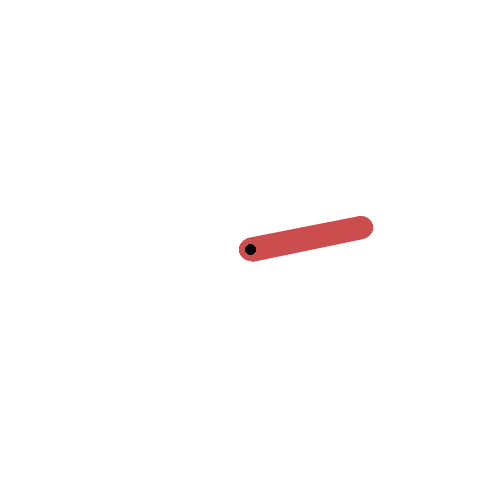

In [80]:
#!pip install gymnasium[classic_control] matplotlib
from torchrl.envs.libs.gym import GymEnv
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import imageio
from IPython.display import Image
from torchrl.envs.transforms import RewardSum

env = GymEnv("Pendulum-v1", from_pixels=True, pixels_only=False)
#env = GymEnv("CartPole-v1", from_pixels=True, pixels_only=False)

env = TransformedEnv(env,
                     StepCounter(),
                     RewardSum())

rollout = env.rollout(max_steps=200)
env.close()

frames = rollout["pixels"].numpy()  

imageio.mimsave("rollout.gif", frames, fps=30)
Image("rollout.gif")   



Let's see what kinds of rewards we were getting.

In [81]:
rollout["next","reward"]

tensor([[ -1.8961],
        [ -2.0367],
        [ -2.3031],
        [ -2.8360],
        [ -3.4907],
        [ -4.5679],
        [ -5.7931],
        [ -7.5628],
        [ -9.4938],
        [-11.7122],
        [-13.4564],
        [-11.3874],
        [ -9.3807],
        [ -7.6062],
        [ -6.3325],
        [ -5.0112],
        [ -3.9533],
        [ -3.2225],
        [ -2.7604],
        [ -2.5656],
        [ -2.5945],
        [ -2.9520],
        [ -3.5844],
        [ -4.4354],
        [ -5.6375],
        [ -7.3907],
        [ -9.5339],
        [-11.5997],
        [-13.2993],
        [-11.4953],
        [ -9.5567],
        [ -7.9773],
        [ -6.5001],
        [ -5.1318],
        [ -4.0424],
        [ -2.9926],
        [ -2.2603],
        [ -1.8115],
        [ -1.6091],
        [ -1.6409],
        [ -1.9422],
        [ -2.5908],
        [ -3.5754],
        [ -4.9859],
        [ -6.2390],
        [ -7.9759],
        [-10.0704],
        [-12.1391],
        [-13.1874],
        [-11.2252],


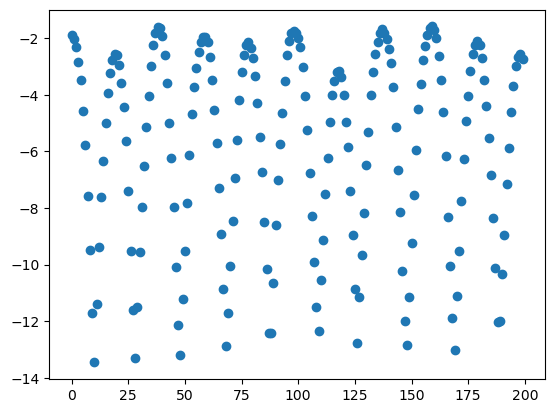

In [82]:
rollout

import matplotlib.pyplot as pyplot

pyplot.scatter(x=rollout["step_count"], y=rollout["next","reward"])

** Things to try **

Try this with cartpole. 

> Why does the animation stop so quickly?

> Why do we always get the same reward? 

# Next steps:

> Let's look at how we can start using RL algorithms to make our agents smarter.

> Check out the offical tutorial [here](https://docs.pytorch.org/rl/stable/tutorials)
> Read up more about [TorchRL Episod Data](https://docs.pytorch.org/rl/stable/reference/data_datasets.html#ted-format) 
> Read up more about [transforms](https://docs.pytorch.org/rl/stable/reference/envs_transforms.html#transforms) 
> Look at more [environments](https://gymnasium.farama.org/) 